In [ ]:
import torch
import torch.nn as nn
import sys 
import os
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
from sklearn.metrics import roc_curve, auc,confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
# Go to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
csv_path = "../data/doge_2h.csv"
from models.model_class import Basic_CNN_LSTM, Optimised_CNN_LSTM, Optimised_Large_CNN_LSTM, Basic_CNN_LSTM_Tuned
from models.load_seq import load_sequence_data
from models.new_metrics import plot_loss_curve, plot_roc_curve, plot_confusion_matrix

In [ ]:
FEATURE_COLUMNS = ["open", "high", "low", "close", "volume", "RSI_14", "ATRr_14"]
X, y, X_train, X_test, y_train, y_test = load_sequence_data(csv_path, features=FEATURE_COLUMNS)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(X_train_t.shape, y_train_t.shape) # Should now correctly show (10471, 48, 7)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

# Hyperparameters
EPOCHS = 50

torch.Size([10471, 48, 7]) torch.Size([10471])


In [ ]:
def train_and_evaluate(model_name, model, train_loader, test_loader, X_test_t, y_test, learning_rate=0.001, weight_decay=0.0):
    """Trains a model with flexible LR and L2 regularization, evaluates it, and plots metrics."""
    print(f"\n{'='*50}\n▶️ STARTING TRAINING FOR: {model_name}\n"
          f"   LR={learning_rate}, L2={weight_decay}\n{'='*50}")

    criterion = nn.BCELoss()
    # Dynamic learning rate and weight decay
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay) 
    
    best_loss = float('inf')
    epoch_losses = [] 

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss_sum = 0 
        
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            outputs = model(Xb).flatten()
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            epoch_loss_sum += loss.item()

        average_epoch_loss = epoch_loss_sum / len(train_loader)
        epoch_losses.append(average_epoch_loss)

        if average_epoch_loss < best_loss:
            best_loss = average_epoch_loss
    

    print(f"✅ Training Complete for {model_name}. Final best loss: {best_loss:.4f}")

    # --- Evaluation ---
    model.eval()
    y_pred_proba = []
    
    with torch.no_grad():
        for Xb, _ in test_loader:
            outputs = model(Xb).flatten()
            y_pred_proba.extend(outputs.numpy())

    # Convert probabilities to binary predictions
    y_pred = (np.array(y_pred_proba) > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    model_auc = roc_auc_score(y_test, y_pred)

    print(f"\n📊 {model_name} Test Metrics (LR={learning_rate}, L2={weight_decay}):")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"AUC: {model_auc:.4f}")

    
    return acc, f1, model_auc, epoch_losses, np.array(y_pred_proba)

In [ ]:
models_to_test = [
    # --- 1. Baseline Architectures (Default LR=0.001, L2=0.0) ---
    # These models primarily test how different fixed-size CNN/LSTM layers compare.
    {"name": "Basic CNN-LSTM (Base)", "model": Basic_CNN_LSTM(), "lr": 0.001, "l2": 0.0},
    {"name": "Optimised CNN-LSTM (Base)", "model": Optimised_CNN_LSTM(), "lr": 0.001, "l2": 0.0},
    {"name": "Optimised Large CNN-LSTM (Base)", "model": Optimised_Large_CNN_LSTM(), "lr": 0.001, "l2": 0.0},
    
    # Baseline for the flexible model (64 LSTM units)
    {"name": "Tuned (Base 64 LSTM)", "model": Basic_CNN_LSTM_Tuned(lstm_hidden_size=64), "lr": 0.001, "l2": 0.0}, 

    # --- 2. LSTM Hidden Size Tuning (Uses Basic_CNN_LSTM_Tuned) ---
    # These models test the impact of sequential memory capacity while keeping LR/L2 constant.
    {"name": "Tuned (LSTM=32)", "model": Basic_CNN_LSTM_Tuned(lstm_hidden_size=32), "lr": 0.001, "l2": 0.0},
    {"name": "Tuned (LSTM=128)", "model": Basic_CNN_LSTM_Tuned(lstm_hidden_size=128), "lr": 0.001, "l2": 0.0},
    
    # Test a different LR/L2 on the large LSTM for exploration
    {"name": "Tuned (LSTM=128, L2=1e-4)", "model": Basic_CNN_LSTM_Tuned(lstm_hidden_size=128), "lr": 0.001, "l2": 1e-4},
    {"name": "Tuned (LR=0.1)", "model": Basic_CNN_LSTM_Tuned(lstm_hidden_size=64), "lr": 0.1, "l2": 0.0}, # to keep aggressive LR test on base Tuned model
]

In [ ]:
results = {}
loss_histories = {}       # New dictionary for loss curves
proba_predictions = {}    # New dictionary for ROC/Confusion Matrix

for config in models_to_test:
    acc, f1, model_auc_result, losses, probas = train_and_evaluate(
        config["name"], 
        config["model"], 
        train_loader, 
        test_loader, 
        X_test_t, 
        y_test,
        learning_rate=config["lr"],
        weight_decay=config["l2"]
    )
    
    results[config["name"]] = {'Accuracy': acc, 'F1': f1, 'AUC': model_auc_result, 'LR': config["lr"], 'L2': config["l2"]}
    loss_histories[config["name"]] = losses 
    proba_predictions[config["name"]] = probas


▶️ STARTING TRAINING FOR: Basic CNN-LSTM (Base)
   LR=0.001, L2=0.0
✅ Training Complete for Basic CNN-LSTM (Base). Final best loss: 0.6906

📊 Basic CNN-LSTM (Base) Test Metrics (LR=0.001, L2=0.0):
Accuracy: 0.5138
F1: 0.3495
AUC: 0.5211

▶️ STARTING TRAINING FOR: Optimised CNN-LSTM (Base)
   LR=0.001, L2=0.0
✅ Training Complete for Optimised CNN-LSTM (Base). Final best loss: 0.6875

📊 Optimised CNN-LSTM (Base) Test Metrics (LR=0.001, L2=0.0):
Accuracy: 0.5057
F1: 0.4070
AUC: 0.5107

▶️ STARTING TRAINING FOR: Optimised Large CNN-LSTM (Base)
   LR=0.001, L2=0.0
✅ Training Complete for Optimised Large CNN-LSTM (Base). Final best loss: 0.6906

📊 Optimised Large CNN-LSTM (Base) Test Metrics (LR=0.001, L2=0.0):
Accuracy: 0.5168
F1: 0.4069
AUC: 0.5223

▶️ STARTING TRAINING FOR: Tuned (Base 64 LSTM)
   LR=0.001, L2=0.0
✅ Training Complete for Tuned (Base 64 LSTM). Final best loss: 0.6901

📊 Tuned (Base 64 LSTM) Test Metrics (LR=0.001, L2=0.0):
Accuracy: 0.5183
F1: 0.5061
AUC: 0.5194

▶️ START

In [ ]:
def plot_comparison_loss_curve(loss_histories, filename="comparison_loss_curve.png"):
    """Plots the training loss curve for multiple models on the same figure."""
    plt.figure(figsize=(10, 6))
    
    for model_name, losses in loss_histories.items():
        plt.plot(losses, label=model_name)
        
    plt.title('Training Loss Comparison Across Models')
    plt.xlabel('Epoch')
    plt.ylabel('Average BCE Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    

def plot_comparison_roc_curve(proba_predictions, y_true, filename="comparison_roc_curve.png"):
    """Plots the ROC curve for multiple models on the same figure."""
    plt.figure(figsize=(8, 8))
    
    for model_name, probas in proba_predictions.items():
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_true, probas)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

    # Plot the random chance line
    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')
    
    plt.title('Receiver Operating Characteristic (ROC) Comparison')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    

def print_comparison_confusion_matrix(proba_predictions, y_true):
    """Prints a comparison table of key Confusion Matrix components."""
    
    summary_data = []
    
    for model_name, probas in proba_predictions.items():
        y_pred = (probas > 0.5).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        
        # cm is [[TN, FP], [FN, TP]]
        TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        
        summary_data.append([model_name, TP, FP, TN, FN])

    # Using pandas to print a neat table
    df = pd.DataFrame(summary_data, columns=["Model", "True Positives (TP)", "False Positives (FP)", "True Negatives (TN)", "False Negatives (FN)"])
    
    print("\n\n📊 Confusion Matrix Component Comparison (Threshold=0.5):")
    print(df.to_markdown(index=False)) # Use .to_string() if pandas is not available

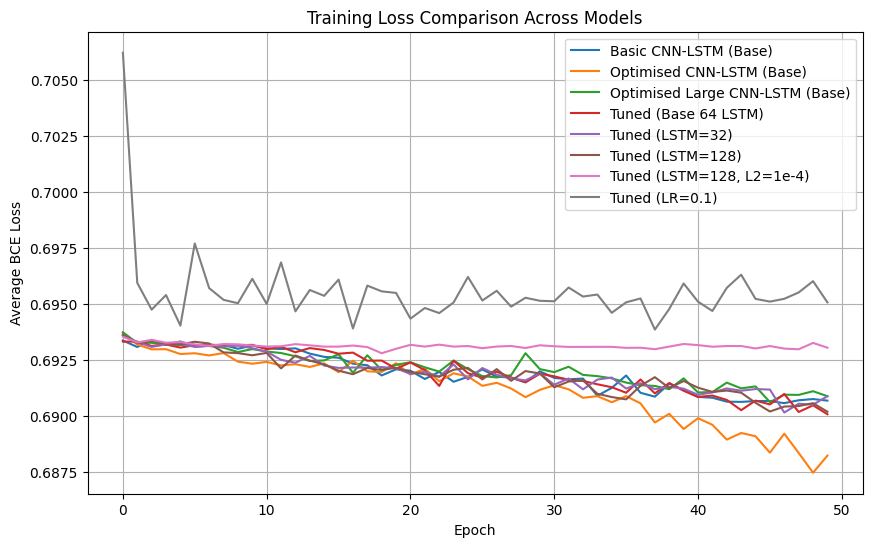

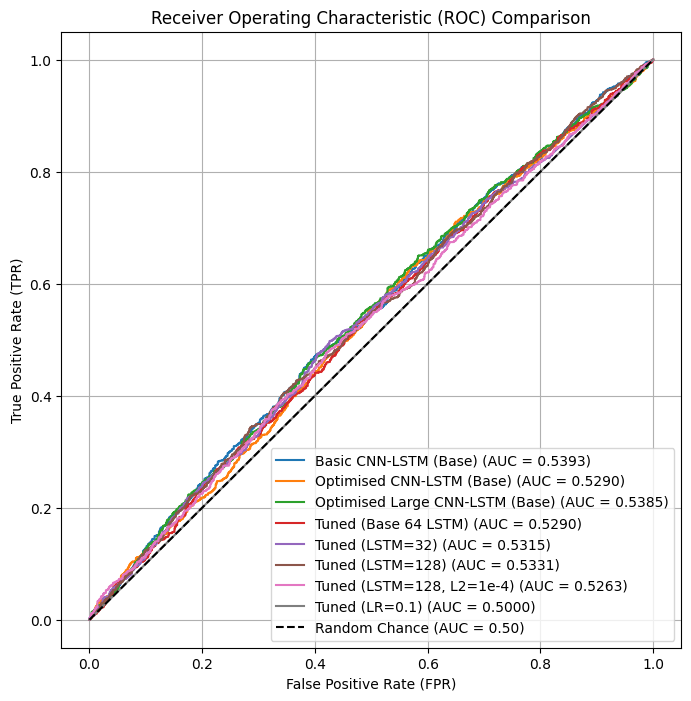



📊 Confusion Matrix Component Comparison (Threshold=0.5):
| Model                           |   True Positives (TP) |   False Positives (FP) |   True Negatives (TN) |   False Negatives (FN) |
|:--------------------------------|----------------------:|-----------------------:|----------------------:|-----------------------:|
| Basic CNN-LSTM (Base)           |                   342 |                    270 |                  1003 |                   1003 |
| Optimised CNN-LSTM (Base)       |                   444 |                    393 |                   880 |                    901 |
| Optimised Large CNN-LSTM (Base) |                   434 |                    354 |                   919 |                    911 |
| Tuned (Base 64 LSTM)            |                   646 |                    562 |                   711 |                    699 |
| Tuned (LSTM=32)                 |                   296 |                    229 |                  1044 |                   1049 |
| T

In [ ]:
plot_comparison_loss_curve(loss_histories)
plot_comparison_roc_curve(proba_predictions, y_test)
print_comparison_confusion_matrix(proba_predictions, y_test)